# Casting defects - the split and the transforms

Between the folders and the network sit four decisions: how the training folder
is cut, how an image becomes a tensor, which constants normalise it, and which
augmentations are allowed. The training script makes all four and the model card
defends three of them in prose. **None of the four had ever been measured.**

This notebook measures them, for the module 03 classifier whose risk events reach
the Quality Steering Cell. The split is written out again from the recorded
parameters, so landing on the same numbers is a reproduction.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries and the shipped configuration, written out here rather than imported from the training script.

In [2]:
import copy
import hashlib
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/03_casting/raw')
META_PATH = Path('../../../models/checkpoints/casting/casting_cv_meta.json')

# The shipped configuration, written out rather than imported.
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
VALIDATION_FRACTION = 0.15
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

meta = json.loads(META_PATH.read_text(encoding='utf-8'))

print(f'python      {sys.version.split()[0]}')
print(f'torch       {torch.__version__}')
print(f'recorded by the shipped run: {meta["train_images"]:,} train, '
      f'{meta["validation_images"]:,} validation, {meta["test_images"]:,} test '
      f'at seed {meta["seed"]}')

python      3.12.10
torch       2.6.0+cu124
recorded by the shipped run: 5,638 train, 995 validation, 715 test at seed 42


## 2. The split, written out again

The rule is a stratified cut: within each class, shuffle with a seeded generator
and take the first 15 per cent for validation. This cell rebuilds it and checks
the result against the two counts the metrics file records.

In [3]:
def split_indices(targets, fraction, seed):
    """Stratified train and validation indices over a label array."""
    generator = np.random.default_rng(seed)
    train_index, validation_index = [], []
    for label in np.unique(targets):
        rows = np.where(targets == label)[0]
        generator.shuffle(rows)
        cut = int(round(len(rows) * fraction))
        validation_index.extend(rows[:cut].tolist())
        train_index.extend(rows[cut:].tolist())
    return sorted(train_index), sorted(validation_index)


folder = ImageFolder(RAW_DIR / 'train')
targets = np.array(folder.targets)
classes = folder.classes
DEFECT_INDEX = folder.class_to_idx['def_front']
print('class_to_idx', folder.class_to_idx, '| defect index', DEFECT_INDEX)

train_index, validation_index = split_indices(targets, VALIDATION_FRACTION, SEED)
print(f'\n{"":<22}{"here":>8}{"recorded":>10}{"delta":>8}')
for name, mine, theirs in (('training images', len(train_index), meta['train_images']),
                           ('validation images', len(validation_index), meta['validation_images'])):
    print(f'{name:<22}{mine:>8,}{theirs:>10,}{mine - theirs:>8}')
print(f'{"overlap between them":<22}{len(set(train_index) & set(validation_index)):>8}')

class_to_idx {'def_front': 0, 'ok_front': 1} | defect index 0

                          here  recorded   delta
training images          5,638     5,638       0
validation images          995       995       0
overlap between them         0


Whether the cut is balanced between the classes, and whether a second call at the same seed returns the same indices.

In [4]:
mix = pd.DataFrame({
    'training': [int((targets[train_index] == i).sum()) for i in range(len(classes))],
    'validation': [int((targets[validation_index] == i).sum()) for i in range(len(classes))],
}, index=classes)
mix.loc['total'] = mix.sum()
mix['validation share'] = (100 * mix['validation'] / (mix['training'] + mix['validation'])).round(2)
print(mix.to_string())

again = split_indices(targets, VALIDATION_FRACTION, SEED)
print(f'\nsplitting a second time at the same seed gives the same indices: '
      f'{again == (train_index, validation_index)}')

           training  validation  validation share
def_front      3194         564             15.01
ok_front       2444         431             14.99
total          5638         995             15.00

splitting a second time at the same seed gives the same indices: True


## 3. Where the duplicated images landed

Notebook 01 found test images that are byte-identical copies of training images.
All of them sit in the train folder, so the cut above divides them and only the
training-side ones were actually fitted. That is the number notebook 03 needs.

This cell also shows why the census has to be done on content: the dataset reuses
filenames across the two folders, so a name collision is not a duplicate picture.

In [5]:
def pixel_hash(path):
    with Image.open(path) as image:
        return hashlib.sha256(np.asarray(image.convert('L')).tobytes()).hexdigest()


t0 = time.time()
test_folder = ImageFolder(RAW_DIR / 'test')
test_hashes = {pixel_hash(path) for path, _ in test_folder.samples}
test_names = {Path(path).name for path, _ in test_folder.samples}
train_hashes = [pixel_hash(path) for path, _ in folder.samples]

by_name = {i for i, (path, _) in enumerate(folder.samples) if Path(path).name in test_names}
by_content = {i for i, value in enumerate(train_hashes) if value in test_hashes}

print(f'hashed {len(train_hashes) + len(test_hashes):,} images in {time.time() - t0:.1f}s\n')
print('train-folder images that also appear in the test folder')
print(f'  matched by filename        {len(by_name):>5}')
print(f'  matched by pixel content   {len(by_content):>5}')
print(f'  same name, different picture  {len(by_name - by_content):>2}   '
      f'(filename matching over-reports by {100 * len(by_name - by_content) / len(by_content):.0f} per cent)')
print(f'  same picture, different name  {len(by_content - by_name):>2}')

hashed 7,348 images in 7.1s

train-folder images that also appear in the test folder
  matched by filename          144
  matched by pixel content      64
  same name, different picture  80   (filename matching over-reports by 125 per cent)
  same picture, different name   0


Which side of the cut each genuine duplicate fell on.

In [6]:
trained_on = by_content & set(train_index)
validated_on = by_content & set(validation_index)

print(f'the {len(by_content)} genuine duplicates land')
print(f'  in the training subset    {len(trained_on):>4}   fitted on, and scored again in the test folder')
print(f'  in the validation subset  {len(validated_on):>4}   used to pick the epoch and the threshold')
print(f'\nso {len(trained_on)} of the {meta["test_images"]} test images were in the training set, '
      f'{100 * len(trained_on) / meta["test_images"]:.1f} per cent of the test folder')
print(f'and {len(trained_on)} of {len(train_index):,} training images, '
      f'{100 * len(trained_on) / len(train_index):.1f} per cent of it')

the 64 genuine duplicates land
  in the training subset      55   fitted on, and scored again in the test folder
  in the validation subset     9   used to pick the epoch and the threshold

so 55 of the 715 test images were in the training set, 7.7 per cent of the test folder
and 55 of 5,638 training images, 1.0 per cent of it


The split we control, beside the one the dataset shipped.

  ✓ Saved → assets\cv\casting_prep_split.png


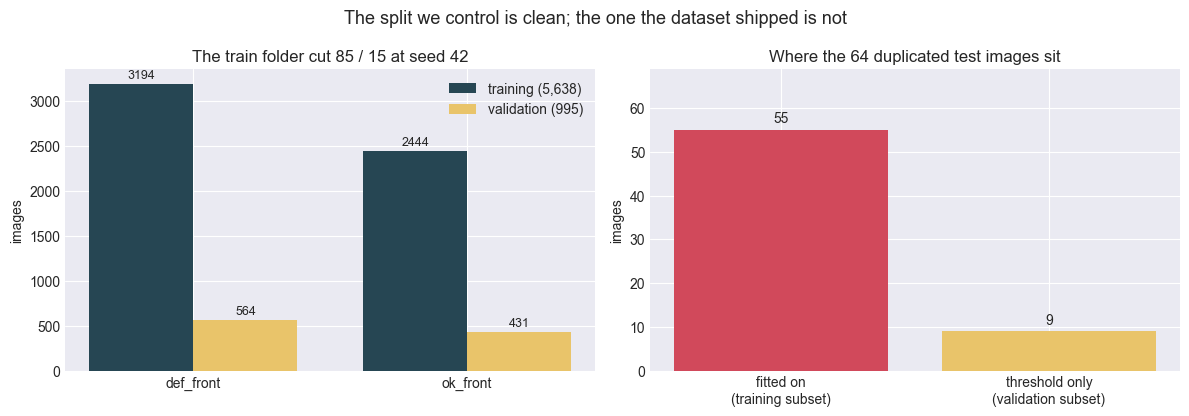

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
width = 0.38
positions = np.arange(len(classes))
for offset, column, colour in ((-width / 2, 'training', '#264653'),
                               (width / 2, 'validation', '#e9c46a')):
    bars = ax.bar(positions + offset, mix.loc[classes, column], width,
                  label=f'{column} ({int(mix.loc["total", column]):,})', color=colour)
    ax.bar_label(bars, fmt='%d', fontsize=9, padding=2)
ax.set_xticks(positions, classes)
ax.set_ylabel('images')
ax.set_title(f'The train folder cut {100 * (1 - VALIDATION_FRACTION):.0f} / '
             f'{100 * VALIDATION_FRACTION:.0f} at seed {SEED}')
ax.legend()

ax = axes[1]
labels = ['fitted on\n(training subset)', 'threshold only\n(validation subset)']
values = [len(trained_on), len(validated_on)]
bars = ax.bar(labels, values, color=['#d1495b', '#e9c46a'])
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_ylabel('images')
ax.set_ylim(0, max(values) * 1.25)
ax.set_title(f'Where the {len(by_content)} duplicated test images sit')
fig.suptitle('The split we control is clean; the one the dataset shipped is not', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_prep_split', subfolder=ASSETS)
plt.show()

## 4. The normalisation, over the whole training subset

Notebook 01 found the images are greyscale in three identical channels. The
pipeline then subtracts a different mean from each channel because those are the
constants ImageNet pretraining used. This cell measures the dataset's own
per-channel mean and standard deviation over all 5,638 training images, with no
sampling.

In [8]:
TO_TENSOR = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

raw_folder = ImageFolder(RAW_DIR / 'train', transform=TO_TENSOR)
raw_loader = DataLoader(Subset(raw_folder, train_index), batch_size=64, shuffle=False,
                        num_workers=0)

t0 = time.time()
total, sum_x, sum_x2 = 0, torch.zeros(3), torch.zeros(3)
for images, _ in raw_loader:
    pixels = images.permute(1, 0, 2, 3).reshape(3, -1)
    total += pixels.shape[1]
    sum_x += pixels.sum(dim=1)
    sum_x2 += (pixels ** 2).sum(dim=1)
dataset_mean = (sum_x / total)
dataset_std = (sum_x2 / total - dataset_mean ** 2).sqrt()

print(f'{len(train_index):,} images, {total:,} pixels per channel, {time.time() - t0:.1f}s\n')
print(f'{"":<16}{"R":>9}{"G":>9}{"B":>9}')
print(f'{"dataset mean":<16}' + ''.join(f'{v:>9.4f}' for v in dataset_mean.tolist()))
print(f'{"ImageNet mean":<16}' + ''.join(f'{v:>9.4f}' for v in IMAGENET_MEAN))
print(f'{"dataset std":<16}' + ''.join(f'{v:>9.4f}' for v in dataset_std.tolist()))
print(f'{"ImageNet std":<16}' + ''.join(f'{v:>9.4f}' for v in IMAGENET_STD))
print(f'\nthe three dataset channels agree to '
      f'{float(dataset_mean.max() - dataset_mean.min()):.2e}, which is what greyscale means')

5,638 images, 282,892,288 pixels per channel, 16.4s

                        R        G        B
dataset mean       0.5641   0.5641   0.5641
ImageNet mean      0.4850   0.4560   0.4060
dataset std        0.2370   0.2370   0.2370
ImageNet std       0.2290   0.2240   0.2250

the three dataset channels agree to 0.00e+00, which is what greyscale means


What those constants leave behind once they are applied, against what the dataset's own statistics would leave.

In [9]:
after = [(float(dataset_mean[c]) - IMAGENET_MEAN[c]) / IMAGENET_STD[c] for c in range(3)]
print('what the normalisation leaves: the mean of each channel afterwards')
print(f'{"":<12}{"R":>9}{"G":>9}{"B":>9}')
print(f'{"ImageNet":<12}' + ''.join(f'{v:>9.4f}' for v in after))
own = [(float(dataset_mean[c]) - float(dataset_mean[c])) / float(dataset_std[c]) for c in range(3)]
print(f'{"dataset own":<12}' + ''.join(f'{v:>9.4f}' for v in own))
print(f'\nthree identical channels enter and leave {max(after) - min(after):.3f} apart. '
      f'That offset carries no information about the part:')
print('it is the same constant in every image, so the first convolution sees a fixed bias')
print('rather than a colour. Nothing is lost, and nothing is gained by keeping three copies.')
print(f'\nThe scale is nearly right by accident: the dataset standard deviation '
      f'{float(dataset_std[0]):.4f} is within')
print(f'{100 * abs(float(dataset_std[0]) - IMAGENET_STD[1]) / IMAGENET_STD[1]:.1f} per cent of the '
      f'ImageNet constants, so the tensor lands in the range the pretrained weights expect.')

what the normalisation leaves: the mean of each channel afterwards
                    R        G        B
ImageNet       0.3456   0.4828   0.7029
dataset own    0.0000   0.0000   0.0000

three identical channels enter and leave 0.357 apart. That offset carries no information about the part:
it is the same constant in every image, so the first convolution sees a fixed bias
rather than a colour. Nothing is lost, and nothing is gained by keeping three copies.

The scale is nearly right by accident: the dataset standard deviation 0.2370 is within
5.8 per cent of the ImageNet constants, so the tensor lands in the range the pretrained weights expect.


The same thing drawn: the three channels before the normalisation and after it.

  ✓ Saved → assets\cv\casting_prep_normalisation.png


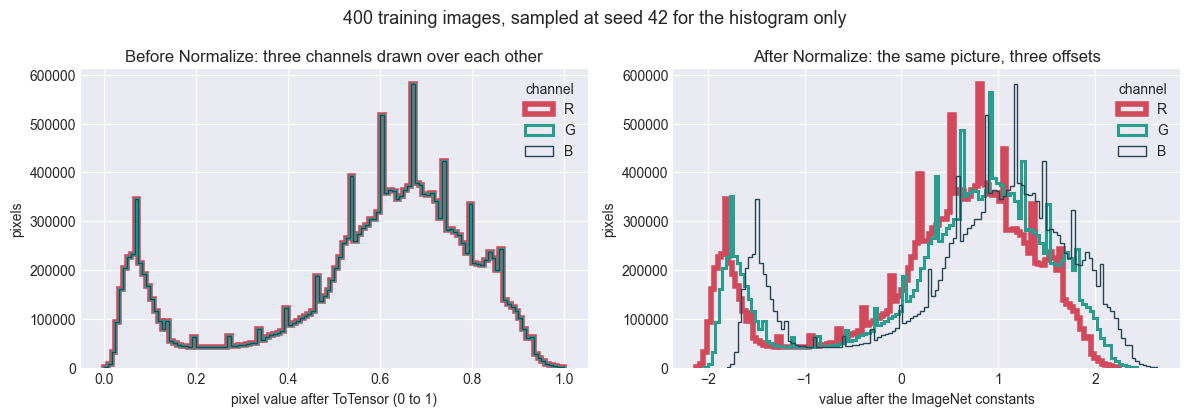

In [10]:
sample_index = list(np.random.default_rng(SEED).choice(train_index, 400, replace=False))
sample = torch.stack([raw_folder[i][0] for i in sample_index])
normalised = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)(sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, data, title, xlabel in (
        (axes[0], sample, 'Before Normalize: three channels drawn over each other',
         'pixel value after ToTensor (0 to 1)'),
        (axes[1], normalised, 'After Normalize: the same picture, three offsets',
         'value after the ImageNet constants')):
    # decreasing linewidth so three identical curves are still three visible curves
    for channel, colour, name, width in ((0, '#d1495b', 'R', 4.0), (1, '#2a9d8f', 'G', 2.2),
                                         (2, '#264653', 'B', 1.0)):
        ax.hist(data[:, channel].flatten().numpy(), bins=120, histtype='step',
                linewidth=width, color=colour, label=name)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('pixels')
    ax.legend(title='channel')
fig.suptitle(f'{len(sample_index)} training images, sampled at seed {SEED} for the histogram only',
             fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_prep_normalisation', subfolder=ASSETS)
plt.show()

## 5. Is the augmentation doing anything

The script defends horizontal and vertical flips and small rotations as the
presentations a part on a conveyor could show. An impeller photographed from the
front is close to circular, so the obvious worry is the opposite: that a flip
returns almost the same picture and the augmentation is decoration.

This cell settles it by measuring how far each transform moves an image, on the
same scale as how far a different part moves it. Every training image, one pass.

In [11]:
resize = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))
rotate = transforms.RandomRotation(10)
torch.manual_seed(SEED)
order = np.random.default_rng(SEED).permutation(train_index)

t0 = time.time()
horizontal, vertical, rotation, fill, neighbour = [], [], [], [], []
previous = None
for position in order:
    image = resize(folder.loader(folder.samples[position][0]))
    array = np.asarray(image.convert('L')).astype(np.int16)
    horizontal.append(np.abs(array - array[:, ::-1]).mean())
    vertical.append(np.abs(array - array[::-1, :]).mean())
    turned = np.asarray(rotate(image).convert('L')).astype(np.int16)
    mask = turned > 0
    rotation.append(np.abs(array - turned)[mask].mean())
    fill.append(100 * (~mask).mean())
    if previous is not None:
        neighbour.append(np.abs(array - previous).mean())
    previous = array

differences = pd.Series({
    'horizontal flip': np.mean(horizontal),
    'vertical flip': np.mean(vertical),
    'rotation up to 10 degrees': np.mean(rotation),
    'a different training image': np.mean(neighbour),
})
print(f'{len(order):,} images in {time.time() - t0:.0f}s\n')
print('mean absolute pixel difference from the original, 0 to 255 scale')
for name, value in differences.items():
    print(f'  {name:<30}{value:>7.2f}   '
          f'{100 * value / differences["a different training image"]:>5.0f} per cent of '
          f'the between-image distance')
print(f'\nrotation fills {np.mean(fill):.2f} per cent of the frame with black on average, '
      f'up to {np.max(fill):.2f} per cent')

5,638 images in 18s

mean absolute pixel difference from the original, 0 to 255 scale
  horizontal flip                 36.75      84 per cent of the between-image distance
  vertical flip                   36.73      84 per cent of the between-image distance
  rotation up to 10 degrees        5.86      13 per cent of the between-image distance
  a different training image      43.66     100 per cent of the between-image distance

rotation fills 3.89 per cent of the frame with black on average, up to 7.34 per cent


A flip moves an image most of the way towards a different part, so the two flips
are real transformations rather than near-copies: the impeller is round in
outline but the blade pattern inside it is not symmetric. The rotation is much
gentler and pays for itself with a black wedge in the corners on every draw.
Neither result overturns the shipped choice; they put a number under a sentence
that had none.

One image under five draws of the training transform, beside the measured distances.

  ✓ Saved → assets\cv\casting_prep_augmentation.png


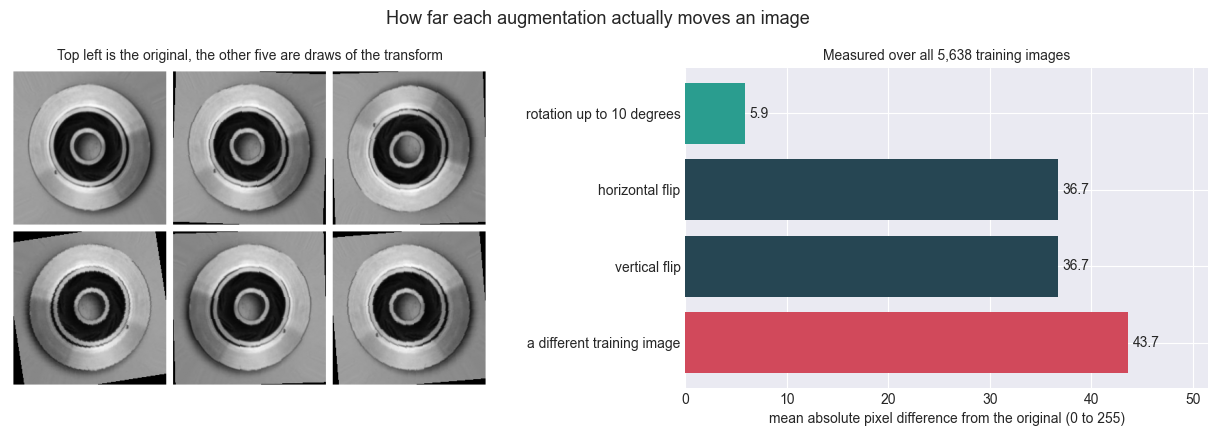

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
example = folder.loader(folder.samples[train_index[0]][0])
base = resize(example)
torch.manual_seed(SEED)
panels = [('original', np.asarray(base.convert('L')))]
augment = transforms.Compose([transforms.RandomHorizontalFlip(),
                              transforms.RandomVerticalFlip(),
                              transforms.RandomRotation(10)])
panels += [(f'draw {i + 1}', np.asarray(augment(base).convert('L'))) for i in range(5)]
tiles = [np.pad(p, 5, constant_values=255) for _, p in panels]
ax.imshow(np.vstack([np.hstack(tiles[:3]), np.hstack(tiles[3:])]), cmap='gray', vmin=0, vmax=255)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title('Top left is the original, the other five are draws of the transform',
             fontsize=10)

ax = axes[1]
order_names = ['rotation up to 10 degrees', 'horizontal flip', 'vertical flip',
               'a different training image']
colours = ['#2a9d8f', '#264653', '#264653', '#d1495b']
bars = ax.barh(range(len(order_names)), [differences[n] for n in order_names], color=colours)
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_yticks(range(len(order_names)), order_names)
ax.invert_yaxis()
ax.set_xlabel('mean absolute pixel difference from the original (0 to 255)')
ax.set_xlim(0, differences.max() * 1.18)
ax.set_title(f'Measured over all {len(order):,} training images', fontsize=10)

fig.suptitle('How far each augmentation actually moves an image', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_prep_augmentation', subfolder=ASSETS)
plt.show()

## 6. Two subsets of one folder, two different transforms

`ImageFolder` holds a single transform, and the two halves of the same folder
need different ones, or the epoch and the threshold get chosen on noise the test
set will not have. The script shallow-copies the dataset object so each view
carries its own transform while sharing the file list.

**The notebook this one replaces got that wrong in the standard way.** It used
`random_split` and then wrote `val_set.dataset.transform`. Both halves of a
`random_split` are views onto one object, so that line reached the training half
too and switched the augmentation off for the whole run, with nothing reporting
an error. This cell checks the construction that avoids it.

In [13]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def view(dataset, transform):
    """A shallow copy carrying its own transform, sharing the file list."""
    other = copy.copy(dataset)
    other.transform = transform
    return other


augmented = view(folder, TRAIN_TRANSFORM)
plain = view(folder, EVAL_TRANSFORM)
probe = train_index[0]

print(f'the two views share one file list: {augmented.samples is plain.samples}')
print(f'they hold different transforms:   {augmented.transform is not plain.transform}')
print(f'the original folder is untouched: {folder.transform is None}')

torch.manual_seed(SEED)
first, second = augmented[probe][0], augmented[probe][0]
print(f'\ntraining view, the same index twice: max difference '
      f'{float((first - second).abs().max()):.4f}   (augmentation is random, so this is not 0)')
first, second = plain[probe][0], plain[probe][0]
print(f'evaluation view, the same index twice: max difference '
      f'{float((first - second).abs().max()):.4f}   (evaluation must be deterministic)')
print(f'training against evaluation view:      max difference '
      f'{float((augmented[probe][0] - plain[probe][0]).abs().max()):.4f}')

the two views share one file list: True
they hold different transforms:   True
the original folder is untouched: True

training view, the same index twice: max difference 3.5014   (augmentation is random, so this is not 0)
evaluation view, the same index twice: max difference 0.0000   (evaluation must be deterministic)
training against evaluation view:      max difference 3.1338


The three loaders, and one batch pulled through the training one.

In [14]:
train_loader = DataLoader(Subset(augmented, train_index), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
validation_loader = DataLoader(Subset(plain, validation_index), batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(ImageFolder(RAW_DIR / 'test', transform=EVAL_TRANSFORM),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                         pin_memory=torch.cuda.is_available())

for name, source in (('train', train_loader), ('validation', validation_loader),
                     ('test', test_loader)):
    print(f'{name:<11}{len(source.dataset):>6,} images  {len(source):>4} batches of {BATCH_SIZE}')

torch.manual_seed(SEED)
batch, labels = next(iter(train_loader))
print(f'\none training batch: {tuple(batch.shape)}  {batch.dtype}')
print(f'  value range {float(batch.min()):.3f} to {float(batch.max()):.3f}')
print(f'  labels {dict(zip(classes, [int((labels == i).sum()) for i in range(len(classes))]))}')

train       5,638 images   177 batches of 32
validation    995 images    32 batches of 32
test          715 images    23 batches of 32



one training batch: (32, 3, 224, 224)  torch.float32
  value range -2.118 to 2.623
  labels {'def_front': 19, 'ok_front': 13}


The same batch turned back into viewable pixels.

  ✓ Saved → assets\cv\casting_prep_batch.png


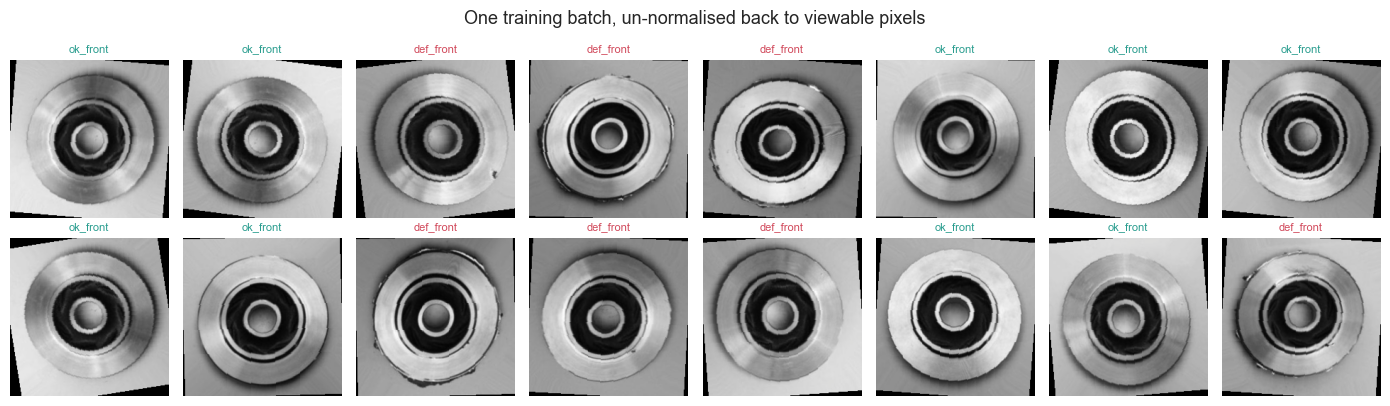

In [15]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
shown = (batch[:16] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4.2))
for ax, image, label in zip(axes.ravel(), shown, labels[:16]):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(classes[int(label)], fontsize=8,
                 color='#d1495b' if int(label) == DEFECT_INDEX else '#2a9d8f')
fig.suptitle('One training batch, un-normalised back to viewable pixels', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_prep_batch', subfolder=ASSETS)
plt.show()

## 7. What this notebook found

Printed from the measurements above rather than typed.

In [16]:
print(f'1. The split reproduces the shipped one exactly: {len(train_index):,} training and '
      f'{len(validation_index):,} validation images at seed {SEED}, stratified to within '
      f'{abs(mix.loc[classes[0], "validation share"] - mix.loc[classes[1], "validation share"]):.2f} '
      f'points between the classes, and identical on a second call.')
print(f'2. Of the {len(by_content)} test images that also sit in the train folder, {len(trained_on)} '
      f'landed in the training subset and {len(validated_on)} in the validation subset. '
      f'{len(trained_on)} of the {meta["test_images"]} test images were therefore fitted on. '
      f'Matching by filename would have said {len(by_name)}, which is wrong by '
      f'{len(by_name) - len(by_content)}.')
print(f'3. The dataset mean is {float(dataset_mean[0]):.4f} in all three channels because the '
      f'images are greyscale. The ImageNet constants push them {max(after) - min(after):.3f} apart, '
      f'a fixed offset that is the same in every image and carries nothing. The standard '
      f'deviation, {float(dataset_std[0]):.4f}, is close enough to the ImageNet one that the '
      f'scale is right.')
print(f'4. A flip moves an image {100 * differences["horizontal flip"] / differences["a different training image"]:.0f} '
      f'per cent as far as a different part does, so the flips are real augmentation. The '
      f'rotation moves it {100 * differences["rotation up to 10 degrees"] / differences["a different training image"]:.0f} '
      f'per cent as far and blacks out {np.mean(fill):.1f} per cent of the frame doing it.')
print(f'\nNotebook 03 rebuilds this split independently, trains on it, and measures the '
      f'{len(trained_on)} fitted-on test images against the operating point.')

1. The split reproduces the shipped one exactly: 5,638 training and 995 validation images at seed 42, stratified to within 0.02 points between the classes, and identical on a second call.
2. Of the 64 test images that also sit in the train folder, 55 landed in the training subset and 9 in the validation subset. 55 of the 715 test images were therefore fitted on. Matching by filename would have said 144, which is wrong by 80.
3. The dataset mean is 0.5641 in all three channels because the images are greyscale. The ImageNet constants push them 0.357 apart, a fixed offset that is the same in every image and carries nothing. The standard deviation, 0.2370, is close enough to the ImageNet one that the scale is right.
4. A flip moves an image 84 per cent as far as a different part does, so the flips are real augmentation. The rotation moves it 13 per cent as far and blacks out 3.9 per cent of the frame doing it.

Notebook 03 rebuilds this split independently, trains on it, and measures the 5